# **Predictive Analytics in Marketing**
## **Project Title**

 Predicting Product Reorders and Customer Buying Behaviour using Machine Learning and Market Basket Analysis

## Dataset:
Instacart Market Basket Analysis (Kaggle)

# Predictive Analytics in Marketing

## Predicting Product Reorders and Customer Buying Behaviour using Machine Learning and Market Basket Analysis

### Business Problem

Retail companies need to understand customer purchasing behaviour to improve customer retention, increase repeat purchases, and optimize product recommendations. Predicting whether a customer will reorder a product enables businesses to design personalized marketing campaigns, improve inventory planning, and increase revenue.

This project develops multiple classification models to predict whether a purchased product will be reordered. Additionally, Market Basket Analysis using Apriori and FP-Growth algorithms is performed to identify products frequently purchased together, enabling effective cross-selling and recommendation strategies.

In [1]:
# Import Libraries
# Data Handling
import pandas as pd
import numpy as np

In [2]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Ignore warnings
import warnings
warnings.filterwarnings("ignore")


In [4]:
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)


In [6]:
# Association Rule Mining
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.frequent_patterns import fpgrowth

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [22]:
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [53]:
# Load Dataset
aisles = pd.read_csv("/content/aisles.csv")
departments = pd.read_csv("/content/departments.csv")
orders = pd.read_csv("/content/orders.csv")
products = pd.read_csv("/content/products.csv")
order_train = pd.read_csv("/content/order_products__train.csv")

In [54]:
datasets = {
    "Orders": orders,
    "Order Products": order_train,
    "Products": products,
    "Aisles": aisles,
    "Departments": departments
}

for name, data in datasets.items():
    print("=" * 50)
    print(name)
    print("=" * 50)
    print("Shape:", data.shape)
    display(data.head())
    print()

Orders
Shape: (3421083, 7)


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0



Order Products
Shape: (1384617, 4)


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1



Products
Shape: (49688, 4)


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13



Aisles
Shape: (134, 2)


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation



Departments
Shape: (21, 2)


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


In [55]:
# Data Understanding
for name, data in datasets.items():

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(data.info())

    print("\nMissing Values")
    print(data.isnull().sum())

    print("\nDuplicate Rows:", data.duplicated().sum())

    print("\n")

Orders
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   eval_set                object 
 3   order_number            int64  
 4   order_dow               int64  
 5   order_hour_of_day       int64  
 6   days_since_prior_order  float64
dtypes: float64(1), int64(5), object(1)
memory usage: 182.7+ MB
None

Missing Values
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

Duplicate Rows: 0


Order Products
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype
---  ------            

In [56]:
# Data Understanding
df = order_train.merge(
    orders,
    on="order_id",
    how="left"
)


In [57]:
df = df.merge(
    products,
    on="product_id",
    how="left"
)


In [58]:
df = df.merge(
    aisles,
    on="aisle_id",
    how="left"
)

In [59]:
df = df.merge(
    departments,
    on="department_id",
    how="left"
)


In [60]:
print(df.shape)

(1384617, 15)


In [61]:
df.head()

,order_id,product_id,add_to_cart_order,reordered,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,aisle_id,department_id,aisle,department
0,1,49302,1,1,112108,train,4,4,10,9.0,Bulgarian Yogurt,120,16,yogurt,dairy eggs
1,1,11109,2,1,112108,train,4,4,10,9.0,Organic 4% Milk Fat Whole Milk Cottage Cheese,108,16,other creams cheeses,dairy eggs
2,1,10246,3,0,112108,train,4,4,10,9.0,Organic Celery Hearts,83,4,fresh vegetables,produce
3,1,49683,4,0,112108,train,4,4,10,9.0,Cucumber Kirby,83,4,fresh vegetables,produce
4,1,43633,5,1,112108,train,4,4,10,9.0,Lightly Smoked Sardines in Olive Oil,95,15,canned meat seafood,canned goods


In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1384617 entries, 0 to 1384616
Data columns (total 15 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   order_id                1384617 non-null  int64  
 1   product_id              1384617 non-null  int64  
 2   add_to_cart_order       1384617 non-null  int64  
 3   reordered               1384617 non-null  int64  
 4   user_id                 1384617 non-null  int64  
 5   eval_set                1384617 non-null  object 
 6   order_number            1384617 non-null  int64  
 7   order_dow               1384617 non-null  int64  
 8   order_hour_of_day       1384617 non-null  int64  
 9   days_since_prior_order  1384617 non-null  float64
 10  product_name            1384617 non-null  object 
 11  aisle_id                1384617 non-null  int64  
 12  department_id           1384617 non-null  int64  
 13  aisle                   1384617 non-null  object 
 14  de

In [63]:
df.describe()

,order_id,product_id,add_to_cart_order,reordered,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order,aisle_id,department_id
count,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06,1.384617e+06
mean,1.706298e+06,2.555624e+04,8.758044e+00,5.985944e-01,1.031128e+05,1.709141e+01,2.701392e+00,1.357759e+01,1.706613e+01,7.130423e+01,9.839777e+00
std,9.897326e+05,1.412127e+04,7.423936e+00,4.901829e-01,5.948715e+04,1.661404e+01,2.167646e+00,4.238458e+00,1.042642e+01,3.810409e+01,6.292830e+00
min,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,4.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00
25%,8.433700e+05,1.338000e+04,3.000000e+00,0.000000e+00,5.173200e+04,6.000000e+00,1.000000e+00,1.000000e+01,7.000000e+00,3.100000e+01,4.000000e+00
50%,1.701880e+06,2.529800e+04,7.000000e+00,1.000000e+00,1.029330e+05,1.100000e+01,3.000000e+00,1.400000e+01,1.500000e+01,8.300000e+01,8.000000e+00
75%,2.568023e+06,3.794000e+04,1.200000e+01,1.000000e+00,1.549590e+05,2.100000e+01,5.000000e+00,1.700000e+01,3.000000e+01,1.070000e+02,1.600000e+01
max,3.421070e+06,4.968800e+04,8.000000e+01,1.000000e+00,2.062090e+05,1.000000e+02,6.000000e+00,2.300000e+01,3.000000e+01,1.340000e+02,2.100000e+01


In [64]:
print(df.isnull().sum())

order_id                  0
product_id                0
add_to_cart_order         0
reordered                 0
user_id                   0
eval_set                  0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
product_name              0
aisle_id                  0
department_id             0
aisle                     0
department                0
dtype: int64


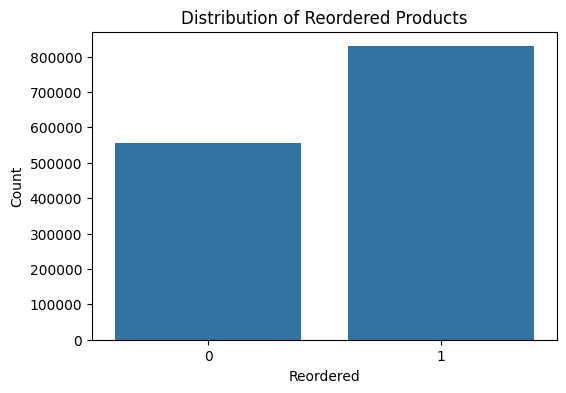

reordered
1    59.859441
0    40.140559
Name: proportion, dtype: float64


In [65]:
# Exploratory Data Analysis (EDA)
#Target Variable Distribution
plt.figure(figsize=(6,4))

sns.countplot(x='reordered', data=df)

plt.title("Distribution of Reordered Products")
plt.xlabel("Reordered")
plt.ylabel("Count")

plt.show()

print(df['reordered'].value_counts(normalize=True)*100)

### Interpretation

The dataset contains both reordered and non-reordered products. The classes are relatively balanced, making it suitable for classification without requiring heavy balancing techniques.

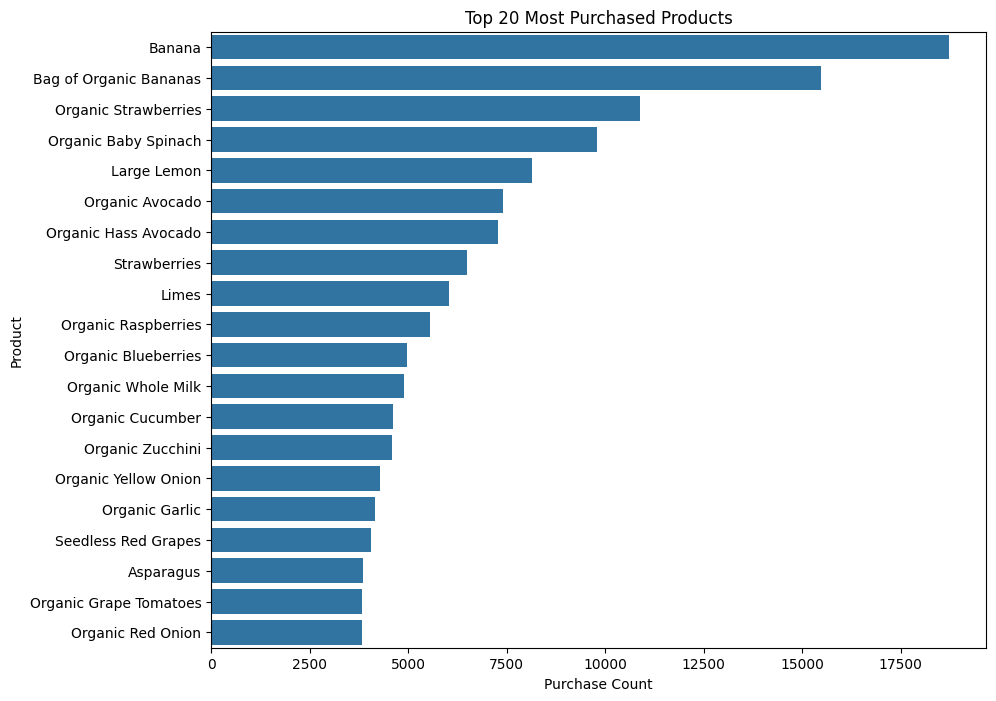

In [66]:
#Top 20 Most Frequently Purchased Products
top_products = (
    df['product_name']
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10,8))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 20 Most Purchased Products")

plt.xlabel("Purchase Count")

plt.ylabel("Product")

plt.show()

### Business Insight

Bananas, Organic Bananas, Organic Strawberries and similar daily-use grocery products dominate customer purchases.

These products should always be maintained with high inventory levels and can be used in promotional campaigns.

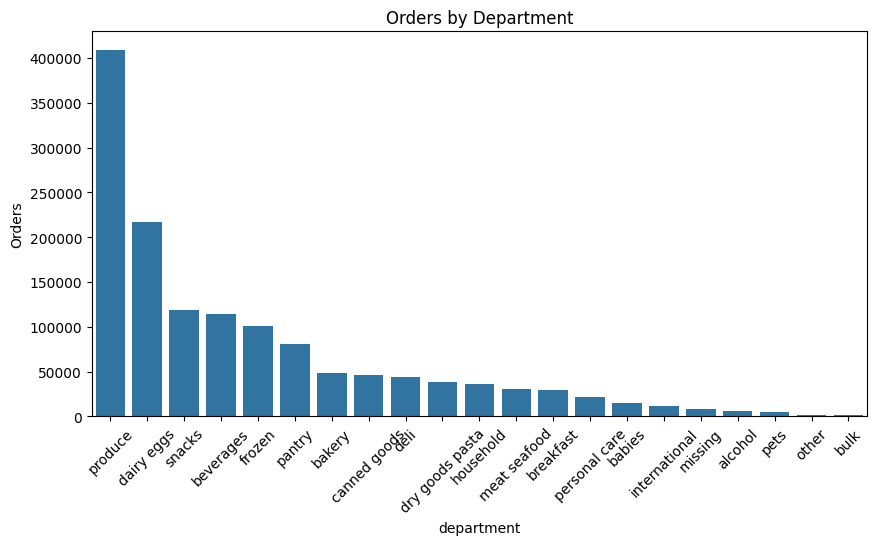

In [67]:
#Top Departments
dept = df['department'].value_counts()

plt.figure(figsize=(10,5))

sns.barplot(
    x=dept.index,
    y=dept.values
)

plt.xticks(rotation=45)

plt.title("Orders by Department")

plt.ylabel("Orders")

plt.show()

### Business Insight

Produce and Dairy departments contribute the largest share of purchases, indicating that fresh food products drive customer engagement.

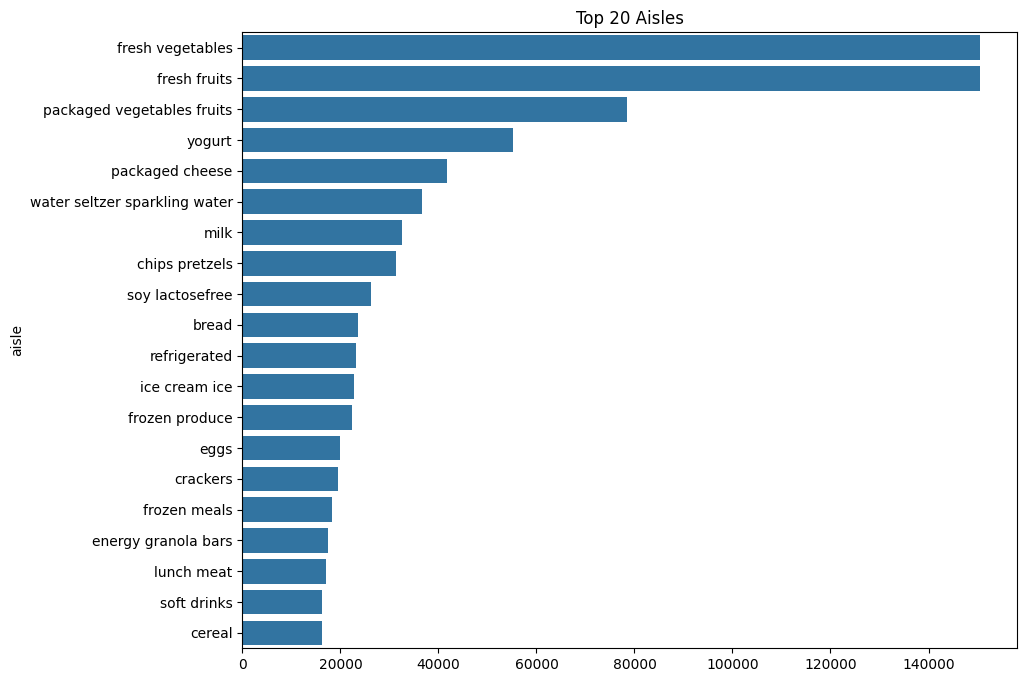

In [68]:
#Top Aisles
aisle = (
    df['aisle']
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10,8))

sns.barplot(
    x=aisle.values,
    y=aisle.index
)

plt.title("Top 20 Aisles")

plt.show()

### Business Insight

Fresh vegetables, fruits and yogurt aisles generate the highest demand.

These aisles are ideal candidates for bundle offers and personalized recommendations.

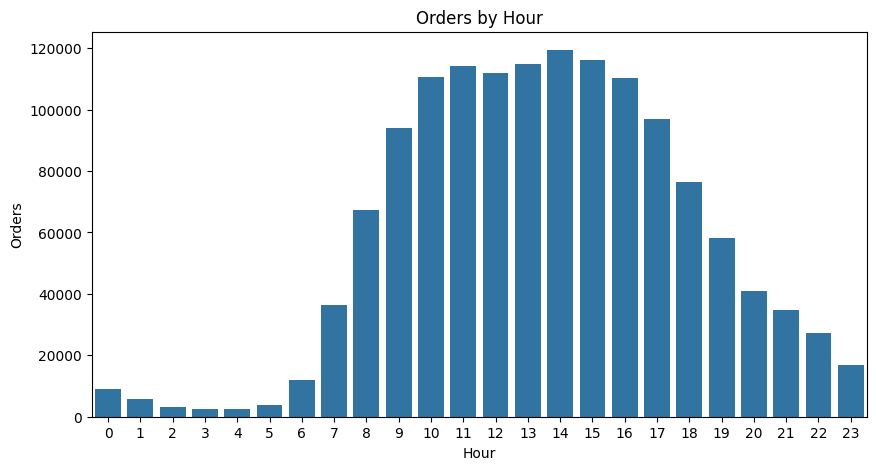

In [69]:
#Orders by Hour
plt.figure(figsize=(10,5))

sns.countplot(
    x='order_hour_of_day',
    data=df
)

plt.title("Orders by Hour")

plt.xlabel("Hour")

plt.ylabel("Orders")

plt.show()

### Business Insight

Customer activity peaks during daytime shopping hours.

Retailers should schedule promotional notifications during these hours to maximize customer engagement.

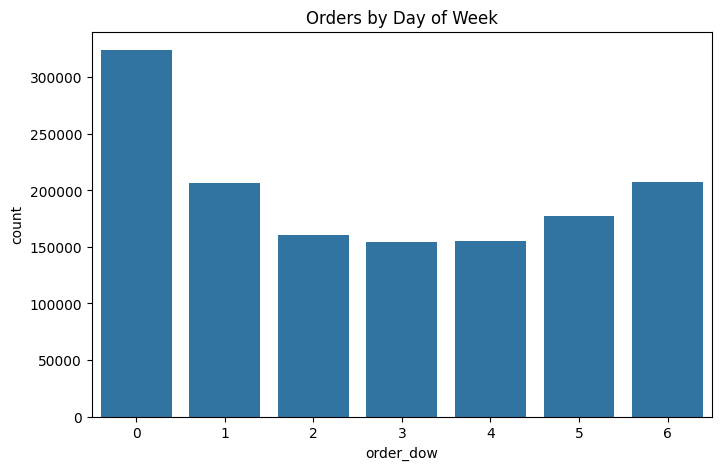

In [70]:
#Orders by Day
plt.figure(figsize=(8,5))

sns.countplot(
    x='order_dow',
    data=df
)

plt.title("Orders by Day of Week")

plt.show()

### Business Insight

Customer purchases vary across the week, helping retailers identify high-demand days for staffing and inventory planning.

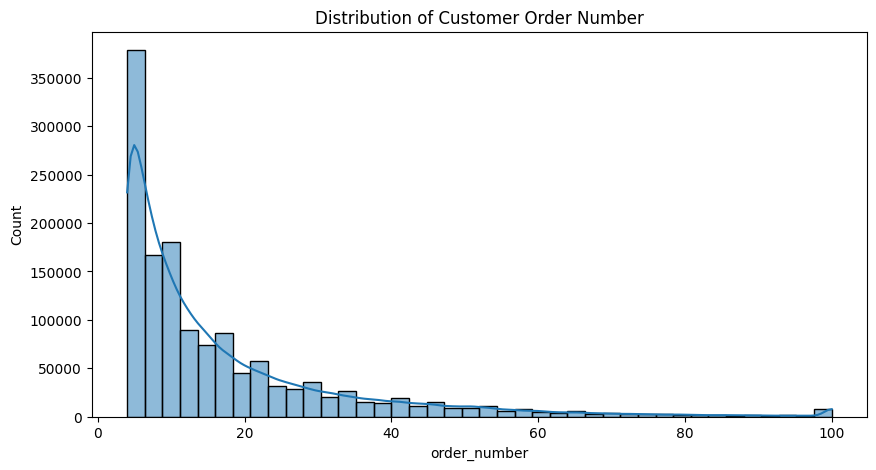

In [71]:
#Distribution of Order Number
plt.figure(figsize=(10,5))

sns.histplot(
    df['order_number'],
    bins=40,
    kde=True
)

plt.title("Distribution of Customer Order Number")

plt.show()

### Business Insight

Many customers have placed multiple orders, suggesting repeat purchasing behaviour and customer loyalty.

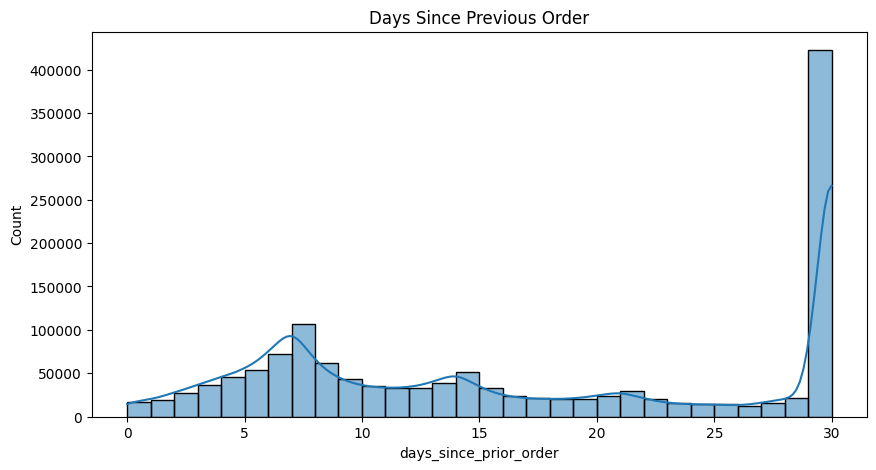

In [72]:
#Days Since Previous Order
plt.figure(figsize=(10,5))

sns.histplot(
    df['days_since_prior_order'].dropna(),
    bins=30,
    kde=True
)

plt.title("Days Since Previous Order")

plt.show()

### Business Insight

Most customers return within a month, indicating opportunities for targeted retention campaigns before the next expected purchase.

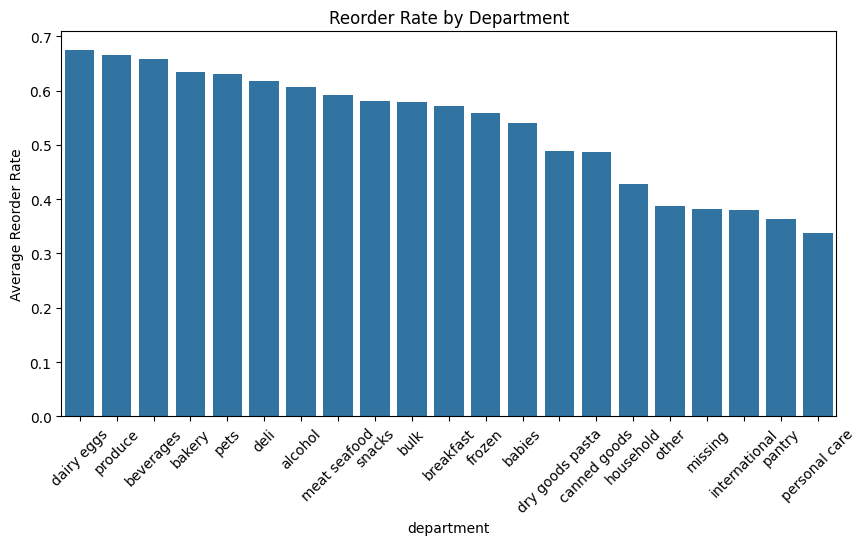

In [73]:
#Reorder Rate by Department
dept_reorder = (
    df.groupby("department")["reordered"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=dept_reorder.index,
    y=dept_reorder.values
)

plt.xticks(rotation=45)

plt.ylabel("Average Reorder Rate")

plt.title("Reorder Rate by Department")

plt.show()

### Business Insight

Departments with higher reorder rates contain products that customers buy regularly. These departments are ideal for loyalty programs and subscription services.

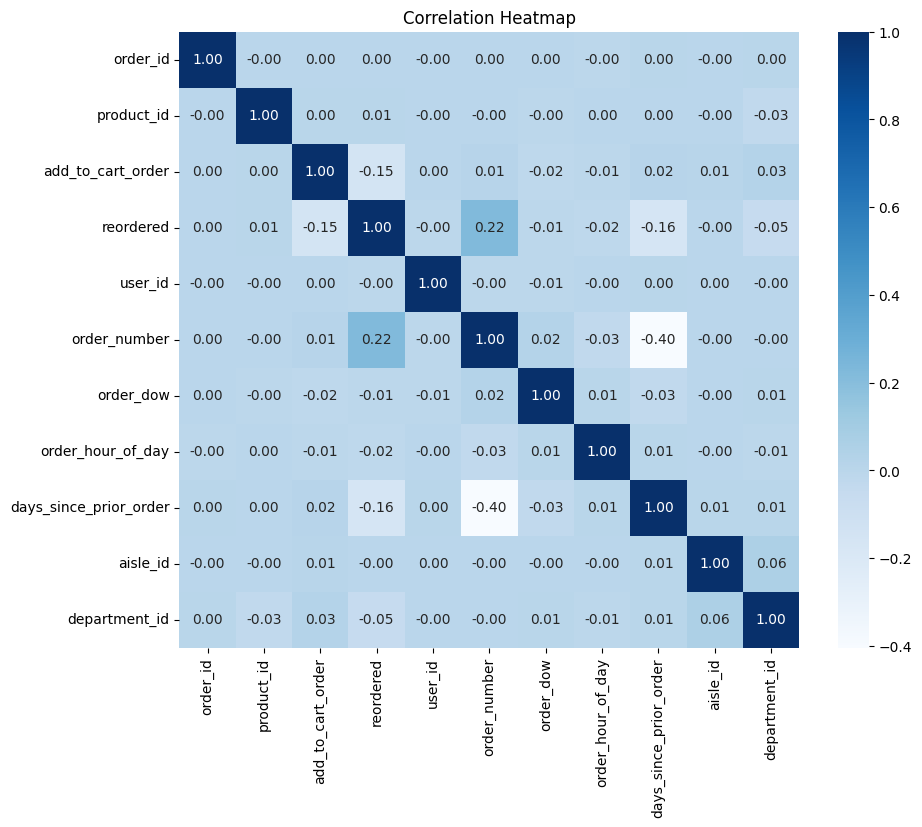

In [74]:
#Correlation Heatmap
plt.figure(figsize=(10,8))

numeric = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric.corr(),
    cmap="Blues",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Business Insight

The correlation analysis highlights relationships among numerical variables. While no extremely strong correlations exist, features such as order number, days since prior order, and cart position may contribute useful information to predictive models.

# Summary of Exploratory Data Analysis

### Key Findings

• Fresh produce and dairy products dominate purchases.

• Customer orders peak during daytime hours.

• Many customers place repeat orders.

• Certain departments exhibit high reorder rates.

• The dataset is suitable for predictive classification.

These findings support the use of machine learning models to predict product reorders and association rule mining to recommend products frequently purchased together.

In [75]:
# Train-Test Split
# Target variable
y = df['reordered']

# Features (remove target)
X = df.drop(columns=['reordered'])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (1107693, 14)
Testing : (276924, 14)


In [76]:
# Leakage-Free Feature Engineering

In [77]:
#Product Purchase Count
product_purchase = (
    X_train.groupby("product_id")
           .size()
           .rename("product_purchase_count")
)

X_train["product_purchase_count"] = X_train["product_id"].map(product_purchase)

X_test["product_purchase_count"] = X_test["product_id"].map(product_purchase)

X_test["product_purchase_count"].fillna(0, inplace=True)

In [78]:
#Product Reorder Rate
temp = X_train.copy()
temp["reordered"] = y_train

product_reorder = (
    temp.groupby("product_id")["reordered"]
        .mean()
        .rename("product_reorder_rate")
)

X_train["product_reorder_rate"] = X_train["product_id"].map(product_reorder)

X_test["product_reorder_rate"] = X_test["product_id"].map(product_reorder)

X_test["product_reorder_rate"].fillna(
    product_reorder.mean(),
    inplace=True
)

In [79]:
#Customer Total Orders
customer_orders = (
    X_train.groupby("user_id")["order_number"]
           .max()
           .rename("customer_total_orders")
)

X_train["customer_total_orders"] = X_train["user_id"].map(customer_orders)

X_test["customer_total_orders"] = X_test["user_id"].map(customer_orders)

X_test["customer_total_orders"].fillna(
    customer_orders.mean(),
    inplace=True
)

In [80]:
#Average Gap Between Orders
customer_gap = (
    X_train.groupby("user_id")["days_since_prior_order"]
           .mean()
           .rename("customer_avg_gap")
)

X_train["customer_avg_gap"] = X_train["user_id"].map(customer_gap)

X_test["customer_avg_gap"] = X_test["user_id"].map(customer_gap)

X_test["customer_avg_gap"].fillna(
    customer_gap.mean(),
    inplace=True
)

In [81]:
#Department Reorder Rate
department_rate = (
    temp.groupby("department")["reordered"]
        .mean()
        .rename("department_reorder_rate")
)

X_train["department_reorder_rate"] = X_train["department"].map(department_rate)

X_test["department_reorder_rate"] = X_test["department"].map(department_rate)

X_test["department_reorder_rate"].fillna(
    department_rate.mean(),
    inplace=True
)

In [82]:
#Aisle Reorder Rate
aisle_rate = (
    temp.groupby("aisle")["reordered"]
        .mean()
        .rename("aisle_reorder_rate")
)

X_train["aisle_reorder_rate"] = X_train["aisle"].map(aisle_rate)

X_test["aisle_reorder_rate"] = X_test["aisle"].map(aisle_rate)

X_test["aisle_reorder_rate"].fillna(
    aisle_rate.mean(),
    inplace=True
)

In [83]:
#Average Cart Position
cart_position = (
    X_train.groupby("product_id")["add_to_cart_order"]
           .mean()
           .rename("avg_cart_position")
)

X_train["avg_cart_position"] = X_train["product_id"].map(cart_position)

X_test["avg_cart_position"] = X_test["product_id"].map(cart_position)

X_test["avg_cart_position"].fillna(
    cart_position.mean(),
    inplace=True
)

In [84]:
#Check engineered features.

X_train.head()

,order_id,product_id,add_to_cart_order,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,product_name,...,department_id,aisle,department,product_purchase_count,product_reorder_rate,customer_total_orders,customer_avg_gap,department_reorder_rate,aisle_reorder_rate,avg_cart_position
1112829,2750640,47766,1,29295,train,4,6,20,14.0,Organic Avocado,...,4,fresh fruits,produce,5965,0.839061,4,14.0,0.664854,0.736256,6.447443
826967,2039644,21903,14,163579,train,48,0,9,10.0,Organic Baby Spinach,...,4,packaged vegetables fruits,produce,7867,0.823058,48,10.0,0.664854,0.656782,7.480997
580895,1427913,17758,7,107057,train,26,1,11,8.0,Strawberry Rhubarb Yoghurt,...,16,yogurt,dairy eggs,412,0.563107,26,8.0,0.674892,0.686399,8.461165
45087,111325,31075,19,73516,train,38,2,12,9.0,Dark Chocolate Morsels,...,13,baking ingredients,pantry,50,0.380000,38,9.0,0.362517,0.316342,11.300000
168910,413370,36066,2,82215,train,4,3,10,30.0,SleepGels Nighttime Sleep Aid,...,2,other,other,10,0.600000,4,30.0,0.393204,0.393204,8.300000


In [85]:
# Data Preprocessing
#Drop text columns.

drop_columns = [
    "product_name",
    "department",
    "aisle",
    "eval_set"
]

X_train = X_train.drop(columns=drop_columns)

X_test = X_test.drop(columns=drop_columns)

In [86]:
#Fill missing values.

X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [87]:
#Scale the numerical features.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [88]:
#Verify everything.

print("Training Features:", X_train_scaled.shape)
print("Testing Features :", X_test_scaled.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels :", y_test.shape)

Training Features: (1107693, 17)
Testing Features : (276924, 17)
Training Labels: (1107693,)
Testing Labels : (276924,)


In [89]:
print(X_train.columns.tolist())

['order_id', 'product_id', 'add_to_cart_order', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order', 'aisle_id', 'department_id', 'product_purchase_count', 'product_reorder_rate', 'customer_total_orders', 'customer_avg_gap', 'department_reorder_rate', 'aisle_reorder_rate', 'avg_cart_position']


In [90]:
X_train = X_train.drop(columns=['order_id'])
X_test = X_test.drop(columns=['order_id'])

print(X_train.shape)
print(X_test.shape)

(1107693, 16)
(276924, 16)


# Machine Learning Model Building

In [91]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import pandas as pd
import numpy as np

In [92]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Histogram Gradient Boosting": HistGradientBoostingClassifier(random_state=42)
}

# Model 1 - Decision Tree Classifier

In [93]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_scaled, y_train)

dt_pred = dt.predict(X_test_scaled)

dt_prob = dt.predict_proba(X_test_scaled)[:,1]

print("Decision Tree training completed.")

Decision Tree training completed.


# Model 2 - Random Forest Classifier

In [94]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)

rf_pred = rf.predict(X_test_scaled)

rf_prob = rf.predict_proba(X_test_scaled)[:,1]

print("Random Forest training completed.")

Random Forest training completed.


# Model 3 - Histogram Gradient Boosting

In [95]:
hgb = HistGradientBoostingClassifier(random_state=42)

hgb.fit(X_train_scaled, y_train)

hgb_pred = hgb.predict(X_test_scaled)

hgb_prob = hgb.predict_proba(X_test_scaled)[:,1]

print("Histogram Gradient Boosting completed.")

Histogram Gradient Boosting completed.


# Model 4 - Naive Bayes

In [96]:
nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

nb_pred = nb.predict(X_test_scaled)

nb_prob = nb.predict_proba(X_test_scaled)[:,1]

print("Naive Bayes completed.")

Naive Bayes completed.


### Now we'll create a smaller dataset

We'll use this only for Logistic Regression and KNN.

### ⚠️ Logistic Regression → Slow on 1.1 million training rows
⚠️ KNN → Very slow and memory-intensive on 1.1 million training rows

# Sampling for Computationally Expensive Models

In [97]:
from sklearn.model_selection import train_test_split

X_train_small, _, y_train_small, _ = train_test_split(
    X_train_scaled,
    y_train,
    train_size=100000,
    stratify=y_train,
    random_state=42
)

print(X_train_small.shape)

(100000, 17)


# Model 5 - Logistic Regression

In [98]:
lr = LogisticRegression(
    max_iter=500,
    random_state=42
)

lr.fit(X_train_small, y_train_small)

lr_pred = lr.predict(X_test_scaled)

lr_prob = lr.predict_proba(X_test_scaled)[:,1]

print("Logistic Regression completed.")

Logistic Regression completed.


# Model 6 - K-Nearest Neighbors

In [99]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train_small, y_train_small)

knn_pred = knn.predict(X_test_scaled)

knn_prob = knn.predict_proba(X_test_scaled)[:,1]

print("KNN completed.")

KNN completed.


# Performance Evaluation and Leaderboard

In [100]:
results = []

predictions = {
    "Decision Tree": (dt_pred, dt_prob),
    "Random Forest": (rf_pred, rf_prob),
    "Histogram Gradient Boosting": (hgb_pred, hgb_prob),
    "Naive Bayes": (nb_pred, nb_prob),
    "Logistic Regression": (lr_pred, lr_prob),
    "KNN": (knn_pred, knn_prob)
}

for model_name, (pred, prob) in predictions.items():

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC AUC": roc_auc_score(y_test, prob)
    })

leaderboard = pd.DataFrame(results)

leaderboard = leaderboard.sort_values(
    by="F1 Score",
    ascending=False
)

leaderboard

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Histogram Gradient Boosting,0.690099,0.714383,0.803553,0.756349,0.740843
1,Random Forest,0.688965,0.718007,0.791084,0.752776,0.737297
4,Logistic Regression,0.675297,0.696217,0.811752,0.749559,0.722598
5,KNN,0.639468,0.684017,0.739155,0.710518,0.661886
3,Naive Bayes,0.651670,0.744118,0.637203,0.686523,0.709405
0,Decision Tree,0.608658,0.674969,0.667819,0.671375,0.594127


In [101]:
leaderboard.style.background_gradient(cmap="Greens")

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Histogram Gradient Boosting,0.690099,0.714383,0.803553,0.756349,0.740843
1,Random Forest,0.688965,0.718007,0.791084,0.752776,0.737297
4,Logistic Regression,0.675297,0.696217,0.811752,0.749559,0.722598
5,KNN,0.639468,0.684017,0.739155,0.710518,0.661886
3,Naive Bayes,0.651670,0.744118,0.637203,0.686523,0.709405
0,Decision Tree,0.608658,0.674969,0.667819,0.671375,0.594127


In [102]:
print("🏆 Best Performing Model")

leaderboard.head(1)

🏆 Best Performing Model


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
2,Histogram Gradient Boosting,0.690099,0.714383,0.803553,0.756349,0.740843
